<a href="https://colab.research.google.com/github/thoppae/kthoppae/blob/main/Model4_E_Commerce_Walmart_Dev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('data.csv')
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


In [ ]:
# prompt: Using dataframe df: df.info()

# Display concise information about the dataframe
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   object 
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   object 
 3   country             5000 non-null   object 
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   object 
 9   email_open_rate     4750 non-null   float64
 10  customer_since      5000 non-null   object 
 11  loyalty_score       5000 non-null   int64  
 12  churn_risk          5000 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 507.9+ KB


,age,avg_order_value,total_orders,last_purchase,is_fraudulent,email_open_rate,loyalty_score,churn_risk
count,5000.000000,4750.000000,5000.000000,5000.000000,5000.000000,4750.000000,5000.000000,5000.000000
mean,48.163200,108.442857,10.027000,180.073200,0.025800,50.714842,50.039400,0.284484
std,17.880797,69.265559,3.163838,104.926518,0.158554,29.098706,28.832151,0.159690
min,18.000000,10.660000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,33.000000,57.805000,8.000000,89.000000,0.000000,25.225000,25.000000,0.160000
50%,48.000000,93.190000,10.000000,178.000000,0.000000,50.950000,50.000000,0.260000
75%,64.000000,142.197500,12.000000,270.000000,0.000000,76.800000,75.000000,0.390000
max,79.000000,555.460000,23.000000,364.000000,1.000000,100.000000,99.000000,0.900000


In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
country,0
avg_order_value,250
total_orders,0
last_purchase,0
is_fraudulent,0
preferred_category,0
email_open_rate,250


In [ ]:
df['email_open_rate'].head()

,email_open_rate
0,25.6
1,12.3
2,NaN
3,42.9
4,5.3


In [ ]:
df['avg_order_value'].head()

,avg_order_value
0,101.08
1,90.39
2,83.28
3,109.90
4,269.38


In [ ]:
df.shape

(5000, 13)

In [ ]:
df['avg_order_value'].fillna(df['avg_order_value'].mean(), inplace=True)
df['email_open_rate'].fillna(df['email_open_rate'].mean(), inplace=True)

In [ ]:
df['gender'].value_counts()
df['country'].value_counts()
df['preferred_category'].value_counts()

,count
preferred_category,
Beauty,1035
Electronics,1021
Home,1004
Fashion,975
Sports,965


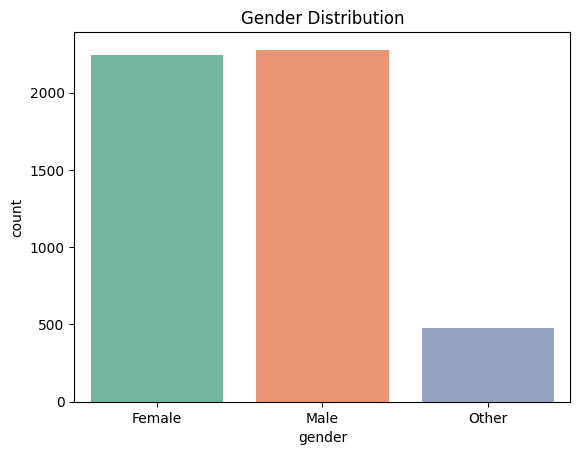

In [ ]:
sns.countplot(x='gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.show()

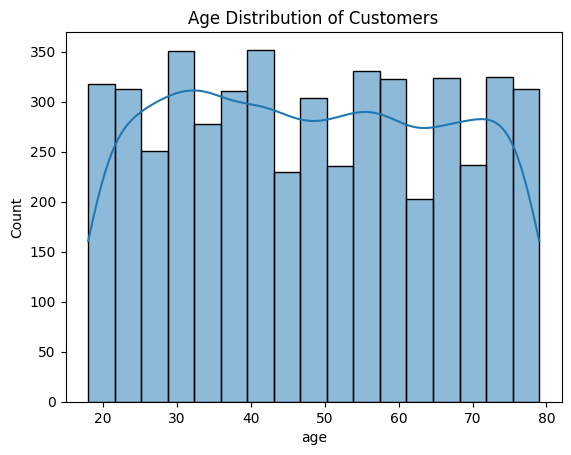

In [ ]:
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution of Customers')
plt.show()

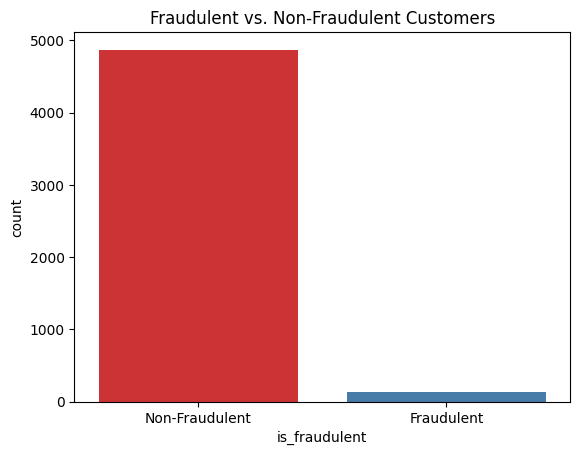

In [ ]:
# prompt: sns.countplot

import matplotlib.pyplot as plt
sns.countplot(x='is_fraudulent', data=df, palette='Set1')
plt.title('Fraudulent vs. Non-Fraudulent Customers')
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'])
plt.show()


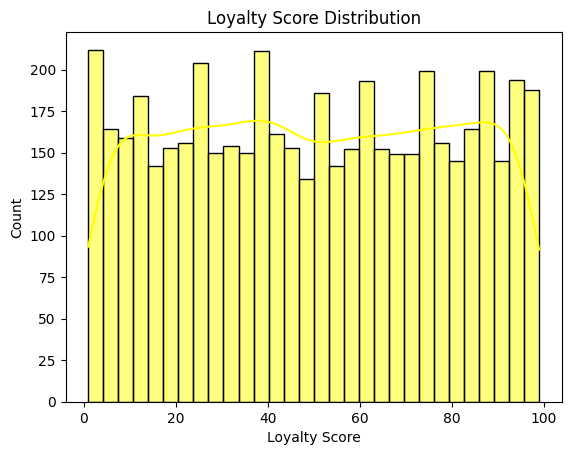

In [ ]:
sns.histplot(df['loyalty_score'], bins=30, color=('yellow'), kde=True)
plt.xlabel('Loyalty Score')
plt.title('Loyalty Score Distribution')
plt.show()

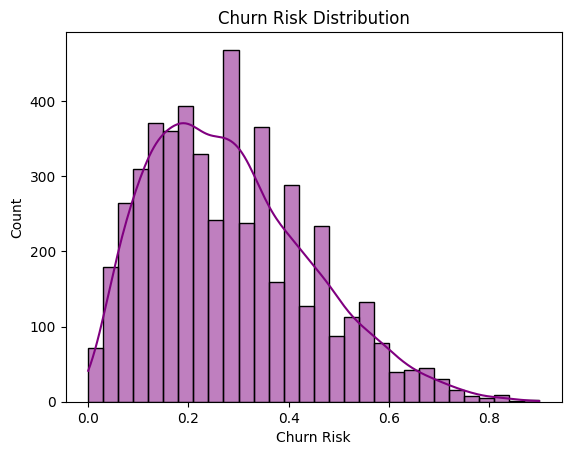

In [ ]:
sns.histplot(df['churn_risk'], bins=30, color=('purple'), kde=True)
plt.xlabel('Churn Risk')
plt.title('Churn Risk Distribution')
plt.show()

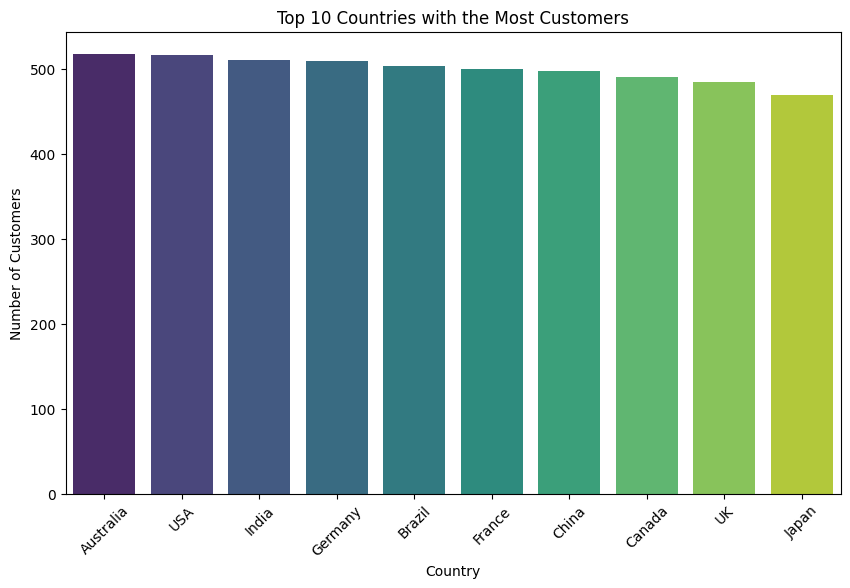

In [ ]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries with the Most Customers')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

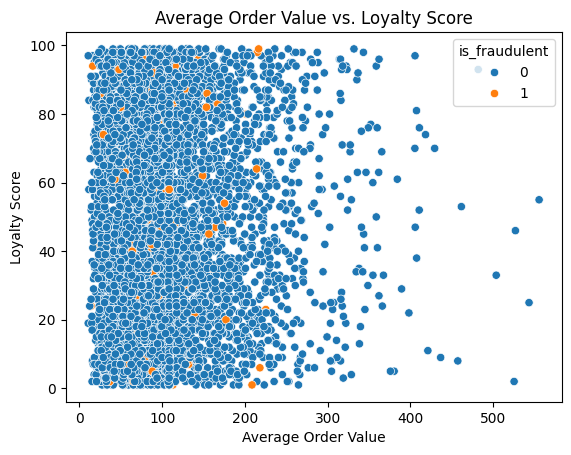

In [ ]:
sns.scatterplot(x='avg_order_value', y='loyalty_score', hue='is_fraudulent', data=df)
plt.title('Average Order Value vs. Loyalty Score')
plt.xlabel('Average Order Value')
plt.ylabel('Loyalty Score')
plt.show()


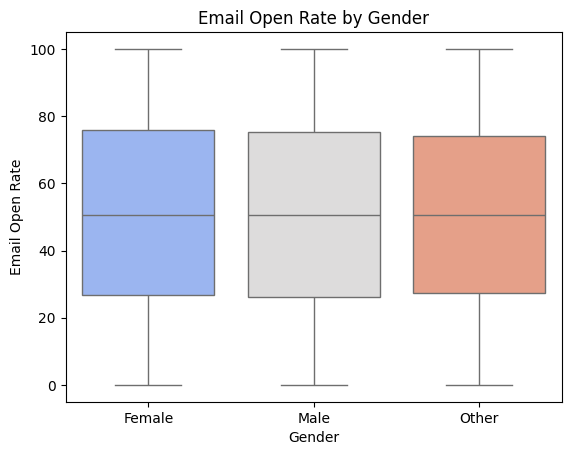

In [ ]:
sns.boxplot(x='gender', y='email_open_rate', data=df, palette='coolwarm')
plt.title('Email Open Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Email Open Rate')
plt.show()

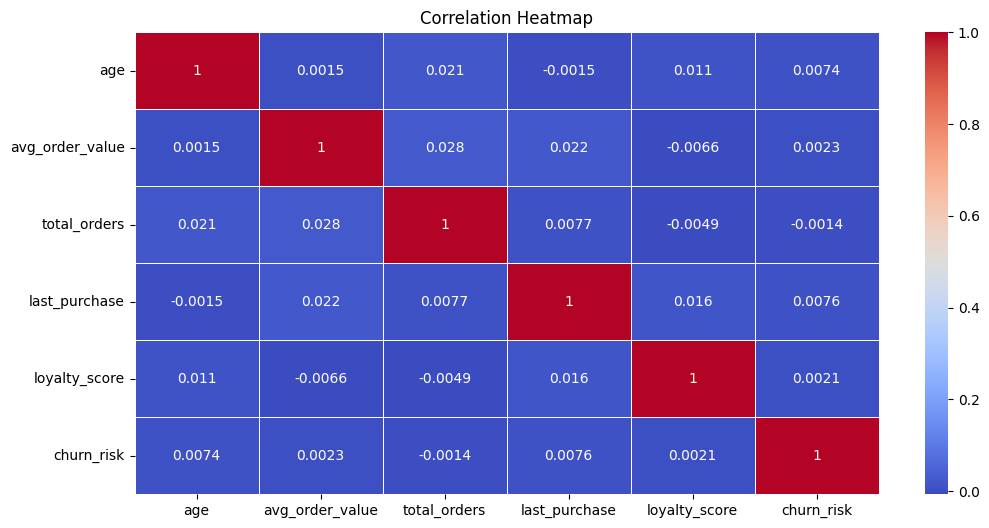

In [ ]:
plt.figure(figsize=(12, 6))
corr = df[['age', 'avg_order_value', 'total_orders', 'last_purchase', 'loyalty_score', 'churn_risk']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

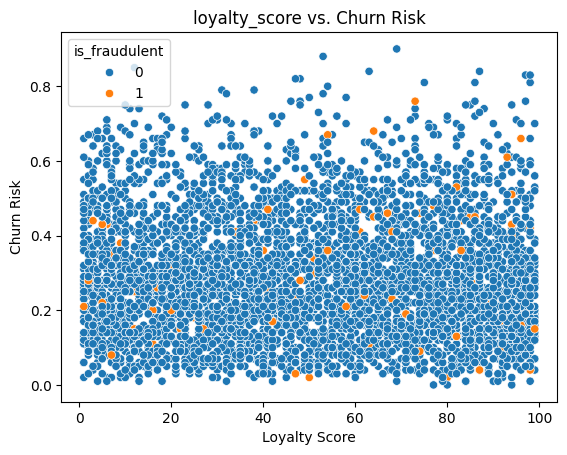

In [ ]:
sns.scatterplot(x='loyalty_score', y='churn_risk', hue='is_fraudulent', data=df)
plt.title('loyalty_score vs. Churn Risk')
plt.xlabel('Loyalty Score')
plt.ylabel('Churn Risk')
plt.show()

Text(0, 0.5, 'Number of Customers')

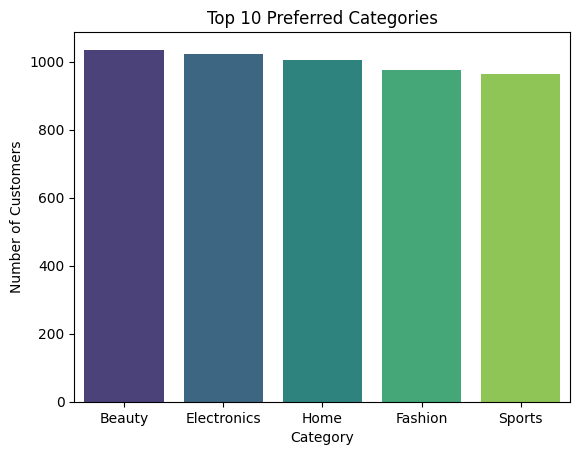

In [ ]:
top_categories = df['preferred_category'].value_counts().head(10)
sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')
plt.title('Top 10 Preferred Categories')
plt.xlabel('Category')
plt.ylabel('Number of Customers')

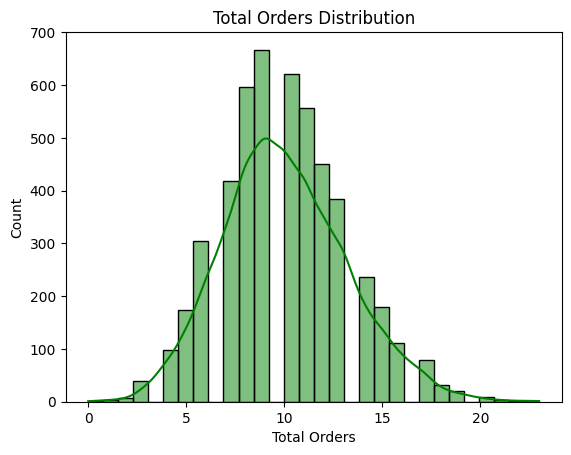

In [ ]:
sns.histplot(df['total_orders'], bins=30, color=('green'), kde=True)
plt.xlabel('Total Orders')
plt.title('Total Orders Distribution')
plt.show()

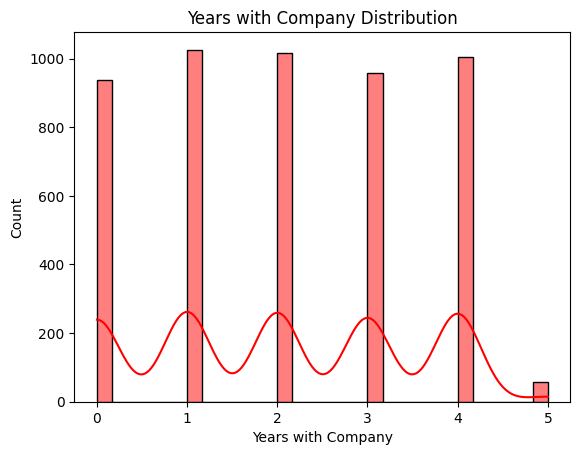

In [ ]:
df['customer_since'] = pd.to_datetime(df['customer_since'])
df['years_with_company'] = (datetime.now() - df['customer_since']).dt.days // 365
sns.histplot(df['years_with_company'], bins=30, color=('red'), kde=True)
plt.xlabel('Years with Company')
plt.title('Years with Company Distribution')
plt.show()





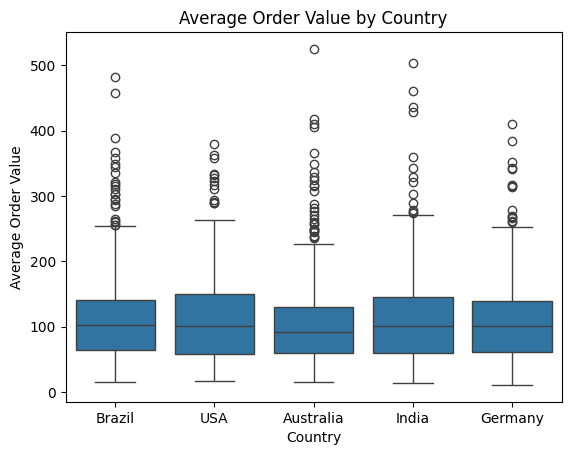

In [ ]:
top_countries = df['country'].value_counts().nlargest(5).index

sns.boxplot(x='country', y='avg_order_value', data=df[df['country'].isin(top_countries)])
plt.title('Average Order Value by Country')
plt.xlabel('Country')
plt.ylabel('Average Order Value')

plt.show()

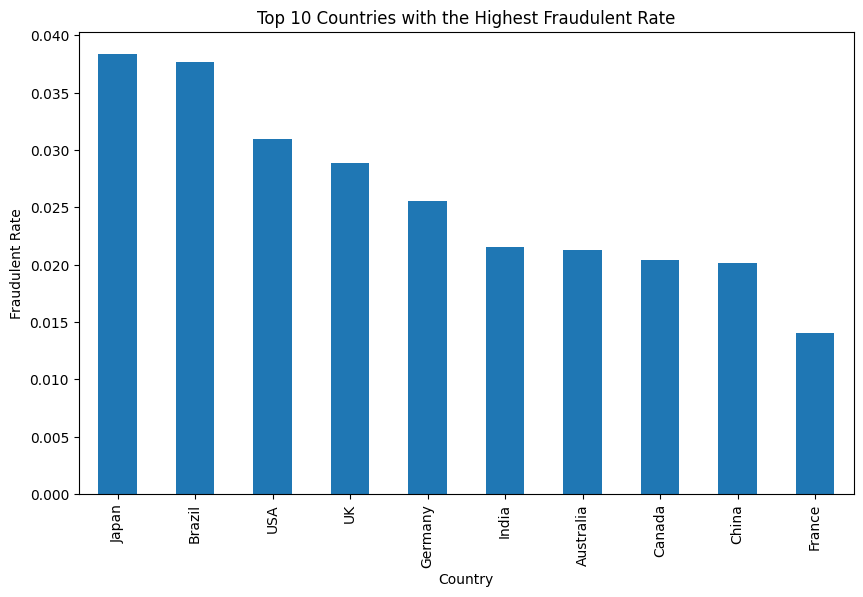

In [ ]:
fraud_rate = df.groupby('country')['is_fraudulent'].mean().sort_values(ascending=False).head(10)
fraud_rate.plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 Countries with the Highest Fraudulent Rate')
plt.xlabel('Country')
plt.ylabel('Fraudulent Rate')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
cat_cols = ['gender', 'country', 'preferred_category']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [ ]:
X = df_encoded.drop(['is_fraudulent', 'customer_id'], axis=1)
y = df_encoded['is_fraudulent']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
def evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.2f}")
    print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
evaluate_model(RandomForestClassifier(), "Random Forest")

Random Forest Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       974
           1       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000



In [ ]:
from xgboost import XGBClassifier

evaluate_model(XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3), "XGBoost with Hyperparameters")

XGBoost with Hyperparameters Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       974
           1       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000



In [ ]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

clust_features = ['avg_order_value', 'loyalty_score', 'churn_risk', 'email_open_rate', 'total_orders']
X = df[clust_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

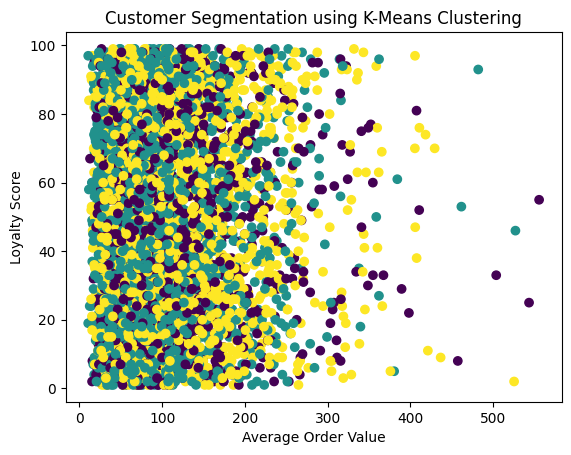

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
plt.scatter(df['avg_order_value'], df['loyalty_score'], c=df['cluster'], cmap='viridis')
plt.xlabel('Average Order Value')
plt.ylabel('Loyalty Score')
plt.title('Customer Segmentation using K-Means Clustering')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

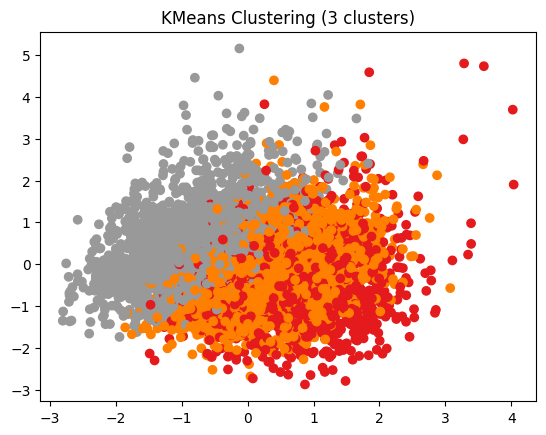

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['kmeans_cluster'], cmap='Set1')
plt.title("KMeans Clustering (3 clusters)")
plt.show()